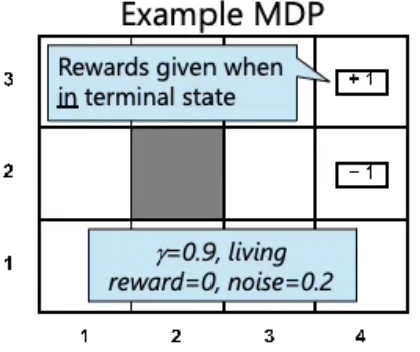

# Value Iteration and Policy Iteration — Step-by-Step Gridworld

This notebook uses the classic **3×4 stochastic Gridworld** example to show exactly how **Value Iteration** and **Policy Iteration** work numerically.

The example uses the same setup commonly shown in the linked Gridworld explanation:

```text
          Column
          1      2      3      4

Row A    A1     A2     A3     +1
Row B    B1    WALL    B3     -1
Row C    C1     C2     C3      C4
```

The agent can choose:

$$
\mathcal{A}=\{\text{Up, Right, Down, Left}\}
$$

but movement is stochastic:

- intended direction: probability \(0.8\),
- perpendicular direction 1: probability \(0.1\),
- perpendicular direction 2: probability \(0.1\).

If movement hits a wall or boundary, the agent remains in the same state.

The discount factor is

$$
\gamma=0.9.
$$

---

## Important Reward Convention

This Gridworld uses a **state-reward convention**:

$$
R(A4)=+1,
$$

$$
R(B4)=-1,
$$

and

$$
R(s)=0
$$

for every other state.

The terminal values therefore appear directly in the value table.

This differs from environments such as standard FrozenLake, where reward is usually attached to the transition that enters the goal.

---

## What Is Being Solved?

There is no trial-and-error training and no sampling of episodes.

The complete model is already known:

$$
P(s'|s,a)
$$

and

$$
R(s).
$$

Dynamic Programming uses this known model to calculate:

- state values,
- action values,
- an improved policy,
- and eventually the optimal policy.

The main goal of this notebook is to make every iteration visible.

## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 2. Define the 3×4 Gridworld

In [2]:
ROWS = 3
COLS = 4

WALL = (1, 1)

TERMINAL_REWARDS = {
    (0, 3): 1.0,   # A4
    (1, 3): -1.0,  # B4
}

ACTIONS = ("Up", "Right", "Down", "Left")

MOVE = {
    "Up": (-1, 0),
    "Right": (0, 1),
    "Down": (1, 0),
    "Left": (0, -1),
}

PERPENDICULAR = {
    "Up": ("Left", "Right"),
    "Right": ("Up", "Down"),
    "Down": ("Right", "Left"),
    "Left": ("Down", "Up"),
}

GAMMA = 0.9

STATES = [
    (row, col)
    for row in range(ROWS)
    for col in range(COLS)
    if (row, col) != WALL
]

STATE_LABELS = {
    (0, 0): "A1",
    (0, 1): "A2",
    (0, 2): "A3",
    (0, 3): "A4",
    (1, 0): "B1",
    (1, 2): "B3",
    (1, 3): "B4",
    (2, 0): "C1",
    (2, 1): "C2",
    (2, 2): "C3",
    (2, 3): "C4",
}

ACTION_SYMBOLS = {
    "Up": "↑",
    "Right": "→",
    "Down": "↓",
    "Left": "←",
}

In [3]:
def reward(state):
    return TERMINAL_REWARDS.get(state, 0.0)


def is_terminal(state):
    return state in TERMINAL_REWARDS


def move(state, action):
    # Terminal states remain terminal.
    if is_terminal(state):
        return state

    row, col = state
    dr, dc = MOVE[action]

    new_row = row + dr
    new_col = col + dc

    # Boundary collision -> stay in the same state.
    if not (0 <= new_row < ROWS and 0 <= new_col < COLS):
        return state

    candidate = (new_row, new_col)

    # Wall collision -> stay in the same state.
    if candidate == WALL:
        return state

    return candidate


def transition_distribution(state, intended_action):
    # Terminal state is absorbing.
    if is_terminal(state):
        return [(1.0, state)]

    side_1, side_2 = PERPENDICULAR[intended_action]

    possible_moves = [
        (0.8, intended_action),
        (0.1, side_1),
        (0.1, side_2),
    ]

    aggregated = {}

    for probability, actual_action in possible_moves:
        next_state = move(state, actual_action)
        aggregated[next_state] = (
            aggregated.get(next_state, 0.0) + probability
        )

    return [
        (probability, next_state)
        for next_state, probability in aggregated.items()
    ]


def expected_next_value(values, state, action):
    return sum(
        probability * values[next_state]
        for probability, next_state
        in transition_distribution(state, action)
    )


def action_backup(values, state, action, gamma=GAMMA):
    return reward(state) + gamma * expected_next_value(
        values,
        state,
        action
    )


def print_values(values, title=None):
    if title:
        print(title)

    for row in range(ROWS):
        row_text = []

        for col in range(COLS):
            state = (row, col)

            if state == WALL:
                row_text.append(" WALL ")
            else:
                row_text.append(f"{values[state]:6.2f}")

        print("  ".join(row_text))


def print_policy(policy, title=None):
    if title:
        print(title)

    for row in range(ROWS):
        row_text = []

        for col in range(COLS):
            state = (row, col)

            if state == WALL:
                row_text.append(" WALL ")
            elif state == (0, 3):
                row_text.append(" +1 ")
            elif state == (1, 3):
                row_text.append(" -1 ")
            else:
                row_text.append(
                    f"  {ACTION_SYMBOLS[policy[state]]}  "
                )

        print("  ".join(row_text))

## 3. Inspect the MDP

In [4]:
print("States:")
for state in STATES:
    print(
        f"{STATE_LABELS[state]:>2} -> "
        f"{state}, reward={reward(state)}"
    )

print("\nActions:", ACTIONS)
print("Discount factor:", GAMMA)

States:
A1 -> (0, 0), reward=0.0
A2 -> (0, 1), reward=0.0
A3 -> (0, 2), reward=0.0
A4 -> (0, 3), reward=1.0
B1 -> (1, 0), reward=0.0
B3 -> (1, 2), reward=0.0
B4 -> (1, 3), reward=-1.0
C1 -> (2, 0), reward=0.0
C2 -> (2, 1), reward=0.0
C3 -> (2, 2), reward=0.0
C4 -> (2, 3), reward=0.0

Actions: ('Up', 'Right', 'Down', 'Left')
Discount factor: 0.9


## 4. Inspect One Stochastic Transition

Suppose the agent is in state `A3` and intends to move **Right**.

The possible outcomes are:

- Right with probability \(0.8\),
- Up with probability \(0.1\),
- Down with probability \(0.1\).

Because `A3` is on the top boundary, the upward slip keeps the agent in `A3`.

In [5]:
state = (0, 2)  # A3
action = "Right"

print("State:", STATE_LABELS[state])
print("Intended action:", action)
print()

for probability, next_state in sorted(
    transition_distribution(state, action),
    key=lambda x: x[1]
):
    print(
        f"P={probability:.1f} -> "
        f"{STATE_LABELS[next_state]}"
    )

print(
    "\nProbability sum:",
    sum(
        probability
        for probability, _
        in transition_distribution(state, action)
    )
)

State: A3
Intended action: Right

P=0.1 -> A3
P=0.8 -> A4
P=0.1 -> B3

Probability sum: 1.0


# Part I — Value Iteration

## 5. Bellman Optimality Update Used in Here

The video presents the Value Iteration Bellman update as

$$
\boxed{
V_{i+1}(s)
\leftarrow
\max_{a\in\mathcal A}
\sum_{s'\in\mathcal S}
P(s'\mid s,a)
\left[
R(s,a,s')+\gamma V_i(s')
\right]
}
$$

This is the general Bellman optimality backup.

For every candidate action \(a\):

1. enumerate all possible next states \(s'\),
2. weight each outcome by $P(s'\mid s,a)$,
3. combine immediate reward and discounted old value,
4. sum the outcomes to get the expected action value,
5. take the maximum over actions.

The 3×4 Gridworld  uses **terminal-state rewards**:

$$
V(+1)=+1,\qquad V(-1)=-1,
$$

with living reward 0 for ordinary states. The terminal values are treated as fixed boundary values. Therefore, for a non-terminal state in this specific example,

$$
R(s,a,s')=0
$$

for the ordinary movement calculation, so the update becomes

$$
V_{i+1}(s)
=
\gamma
\max_a
\sum_{s'}P(s'\mid s,a)V_i(s').
$$

The terminal cells themselves are kept fixed at \(+1\) and \(-1\).

This is why the first sweep creates the terminal values, and later sweeps propagate those values into neighboring states.

---

## Synchronous Updating

This notebook uses **synchronous Value Iteration**.

Every value in iteration \(i+1\) is calculated only from the completed values in iteration \(i\).

Values calculated earlier in the current sweep are not used until the next sweep.

In [6]:
def value_iteration_sweep(old_values, gamma=GAMMA):
    new_values = old_values.copy()
    greedy_actions = {}

    for state in STATES:
        if is_terminal(state):
            new_values[state] = reward(state)
            continue

        q_values = {
            action: action_backup(
                old_values,
                state,
                action,
                gamma
            )
            for action in ACTIONS
        }

        best_action = max(
            ACTIONS,
            key=lambda action: q_values[action]
        )

        new_values[state] = q_values[best_action]
        greedy_actions[state] = best_action

    return new_values, greedy_actions

## 6. Iteration 0

In [7]:
V = {
    state: 0.0
    for state in STATES
}

print_values(
    V,
    title="V0 — before any Bellman update"
)

V0 — before any Bellman update
  0.00    0.00    0.00    0.00
  0.00   WALL     0.00    0.00
  0.00    0.00    0.00    0.00


Initially,

$$
V_0(s)=0
$$

for every state, including the terminal states.

The first Bellman sweep inserts the state rewards \(+1\) and \(-1\).

## 7. Iteration 1

In [8]:
V1, policy1 = value_iteration_sweep(V)

print_values(
    V1,
    title="V1 — after one sweep"
)

V1 — after one sweep
  0.00    0.00    0.00    1.00
  0.00   WALL     0.00   -1.00
  0.00    0.00    0.00    0.00


Only the two terminal states have nonzero values after the first sweep:

$$
V_1(A4)=1
$$

and

$$
V_1(B4)=-1.
$$

The neighboring states cannot use those values until the next synchronous sweep.

## 8. Iteration 2 — Manual Calculation for A3

Now calculate `A3`, the state immediately left of \(+1\).

For the action **Right**:

- \(0.8\) reaches \(A4\), whose old value is \(1\),
- \(0.1\) slips Up, hits the boundary, and stays in \(A3\), whose old value is \(0\),
- \(0.1\) slips Down to \(B3\), whose old value is \(0\).

Therefore,

$$
Q_2(A3,\text{Right})
=
0
+
0.9
[
0.8(1)
+
0.1(0)
+
0.1(0)
].
$$

So,

$$
Q_2(A3,\text{Right})
=
0.72.
$$

The code below calculates **all four actions from the model**, rather than inserting the values manually.

In [9]:
state = (0, 2)  # A3

print("Using V1 values to calculate V2(A3):\n")

q_values_A3_iter2 = {}

for action in ACTIONS:
    q_value = action_backup(
        V1,
        state,
        action,
        GAMMA
    )

    q_values_A3_iter2[action] = q_value

    print(
        f"{action:>5}: "
        f"{q_value:.4f}"
    )

best_action = max(
    ACTIONS,
    key=lambda action: q_values_A3_iter2[action]
)

print("\nBest action:", best_action)
print(
    "V2(A3) =",
    q_values_A3_iter2[best_action]
)

Using V1 values to calculate V2(A3):

   Up: 0.0900
Right: 0.7200
 Down: 0.0900
 Left: 0.0000

Best action: Right
V2(A3) = 0.7200000000000001


In [10]:
V2, policy2 = value_iteration_sweep(V1)

print_values(
    V2,
    title="V2 — after two sweeps"
)

V2 — after two sweeps
  0.00    0.00    0.72    1.00
  0.00   WALL     0.00   -1.00
  0.00    0.00    0.00    0.00


This reproduces the important value

$$
\boxed{V_2(A3)=0.72}.
$$

## 9. Iteration 3 — Why 0.72 Becomes About 0.78

This is the step that often causes confusion.

At iteration 3, `A3` is calculated using **V2**, not V1 and not partially updated V3 values.

For intended action **Right**:

- \(0.8\) reaches terminal \(A4\) with value \(1\),
- \(0.1\) slips Up and remains in `A3`; now the old value of `A3` is \(0.72\),
- \(0.1\) slips Down to `B3`; its V2 value is \(0\).

Therefore,

$$
Q_3(A3,\text{Right})
=
0.9
[
0.8(1)
+
0.1(0.72)
+
0.1(0)
].
$$

$$
=
0.9(0.8+0.072)
$$

$$
=
0.7848
$$

or approximately

$$
\boxed{0.78}.
$$

In [11]:
state = (0, 2)  # A3

print("V2 values involved:")
print("V2(A4) =", V2[(0, 3)])
print("V2(A3) =", V2[(0, 2)])
print("V2(B3) =", V2[(1, 2)])

right_value = action_backup(
    V2,
    state,
    "Right",
    GAMMA
)

print(
    "\nModel-calculated Q(A3, Right) =",
    right_value
)

V2 values involved:
V2(A4) = 1.0
V2(A3) = 0.7200000000000001
V2(B3) = 0.0

Model-calculated Q(A3, Right) = 0.7848000000000002


### Calculate All Four Actions at A3

In [12]:
q_values_A3_iter3 = {}

for action in ACTIONS:
    q_value = action_backup(
        V2,
        (0, 2),
        action,
        GAMMA
    )

    q_values_A3_iter3[action] = q_value

    print(
        f"{action:>5}: "
        f"{q_value:.4f}"
    )

print(
    "\nV3(A3) = max =",
    max(q_values_A3_iter3.values())
)

   Up: 0.6084
Right: 0.7848
 Down: 0.0900
 Left: 0.0648

V3(A3) = max = 0.7848000000000002


### Calculate A2

In [13]:
state = (0, 1)  # A2

q_values_A2_iter3 = {
    action: action_backup(
        V2,
        state,
        action,
        GAMMA
    )
    for action in ACTIONS
}

for action in ACTIONS:
    print(
        f"{action:>5}: "
        f"{q_values_A2_iter3[action]:.4f}"
    )

print(
    "\nV3(A2) =",
    max(q_values_A2_iter3.values())
)

   Up: 0.0648
Right: 0.5184
 Down: 0.0648
 Left: 0.0000

V3(A2) = 0.5184000000000001


The best action gives approximately

$$
\boxed{V_3(A2)=0.52}.
$$

### Calculate B3

In [14]:
state = (1, 2)  # B3

q_values_B3_iter3 = {
    action: action_backup(
        V2,
        state,
        action,
        GAMMA
    )
    for action in ACTIONS
}

for action in ACTIONS:
    print(
        f"{action:>5}: "
        f"{q_values_B3_iter3[action]:.4f}"
    )

print(
    "\nV3(B3) =",
    max(q_values_B3_iter3.values())
)

   Up: 0.4284
Right: -0.6552
 Down: -0.0900
 Left: 0.0648

V3(B3) = 0.4284000000000001


For `B3`, the best action is Up.

Its expected value is

$$
0.9
[
0.8(0.72)
+
0.1(0)
+
0.1(-1)
]
$$

$$
=
0.4284
$$

or approximately

$$
\boxed{0.43}.
$$

In [15]:
V3, policy3 = value_iteration_sweep(V2)

print_values(
    V3,
    title="V3 — after three sweeps"
)

V3 — after three sweeps
  0.00    0.52    0.78    1.00
  0.00   WALL     0.43   -1.00
  0.00    0.00    0.00    0.00


The three important values are now visible together:

$$
A2 \approx 0.52,
$$

$$
A3 \approx 0.78,
$$

$$
B3 \approx 0.43.
$$

## 10. Continue the Iterations

In [16]:
value_history = [V]

current_values = V.copy()

for iteration in range(1, 21):
    current_values, _ = value_iteration_sweep(
        current_values
    )
    value_history.append(
        current_values.copy()
    )

for iteration in [0, 1, 2, 3, 4, 5, 6, 10, 20]:
    print_values(
        value_history[iteration],
        title=f"Iteration {iteration}"
    )
    print()

Iteration 0
  0.00    0.00    0.00    0.00
  0.00   WALL     0.00    0.00
  0.00    0.00    0.00    0.00

Iteration 1
  0.00    0.00    0.00    1.00
  0.00   WALL     0.00   -1.00
  0.00    0.00    0.00    0.00

Iteration 2
  0.00    0.00    0.72    1.00
  0.00   WALL     0.00   -1.00
  0.00    0.00    0.00    0.00

Iteration 3
  0.00    0.52    0.78    1.00
  0.00   WALL     0.43   -1.00
  0.00    0.00    0.00    0.00

Iteration 4
  0.37    0.66    0.83    1.00
  0.00   WALL     0.51   -1.00
  0.00    0.00    0.31    0.00

Iteration 5
  0.51    0.72    0.84    1.00
  0.27   WALL     0.55   -1.00
  0.00    0.22    0.37    0.13

Iteration 6
  0.59    0.73    0.85    1.00
  0.41   WALL     0.57   -1.00
  0.21    0.31    0.43    0.19

Iteration 10
  0.64    0.74    0.85    1.00
  0.56   WALL     0.57   -1.00
  0.48    0.41    0.47    0.27

Iteration 20
  0.64    0.74    0.85    1.00
  0.57   WALL     0.57   -1.00
  0.49    0.43    0.48    0.28



The values propagate outward from the terminal states.

Notice that information does not instantly jump across the grid. It moves through repeated Bellman backups.

## 11. Value Iteration Until Convergence

In [17]:
def run_value_iteration(
    theta=1e-10,
    gamma=GAMMA,
    max_iterations=10000
):
    values = {
        state: 0.0
        for state in STATES
    }

    history = [values.copy()]
    deltas = []

    for iteration in range(1, max_iterations + 1):
        new_values, greedy_policy = value_iteration_sweep(
            values,
            gamma
        )

        delta = max(
            abs(
                new_values[state]
                - values[state]
            )
            for state in STATES
        )

        values = new_values

        history.append(
            values.copy()
        )

        deltas.append(delta)

        if delta < theta:
            return (
                values,
                greedy_policy,
                history,
                deltas,
                iteration
            )

    raise RuntimeError(
        "Value Iteration did not converge."
    )


(
    V_star,
    policy_star_vi,
    vi_history,
    vi_deltas,
    vi_iterations
) = run_value_iteration()

print(
    "Converged after",
    vi_iterations,
    "sweeps."
)

print()

print_values(
    V_star,
    title="Converged V*"
)

print()

print_policy(
    policy_star_vi,
    title="Greedy policy from V*"
)

Converged after 35 sweeps.

Converged V*
  0.64    0.74    0.85    1.00
  0.57   WALL     0.57   -1.00
  0.49    0.43    0.48    0.28

Greedy policy from V*
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      ←      ↑      ←  


## 12. Value Iteration Convergence

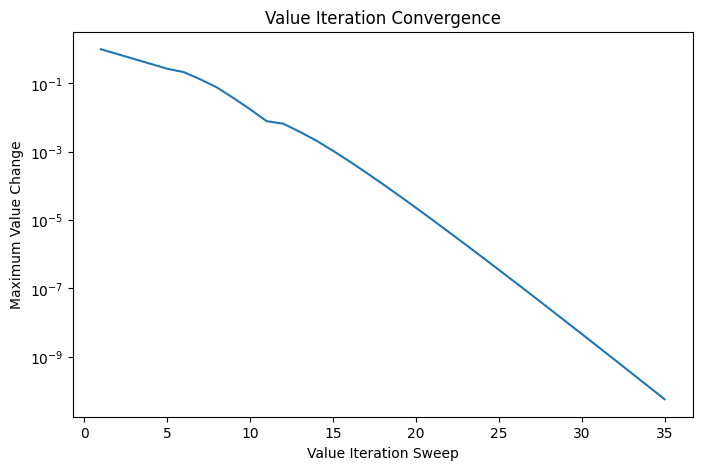

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(vi_deltas) + 1),
    vi_deltas
)

plt.yscale("log")
plt.xlabel("Value Iteration Sweep")
plt.ylabel("Maximum Value Change")
plt.title("Value Iteration Convergence")
plt.show()

Value Iteration stops when

$$
\max_s
|V_{k+1}(s)-V_k(s)|
<
\theta.
$$

The policy is then extracted greedily:

$$
\pi^*(s)
=
\arg\max_a
\left[
R(s)
+
\gamma
\sum_{s'}
P(s'|s,a)V^*(s')
\right].
$$

# Part II — Policy Iteration

Value Iteration repeatedly updates the optimal value estimate directly.

Policy Iteration takes a different route:

$$
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}
\rightarrow
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}
\rightarrow \cdots
$$

There are therefore **two loops**.

### Inner loop

Evaluate the current policy until its values converge.

### Outer loop

Improve the policy and repeat until the policy stops changing.

## 13. Start with an Initial Policy

To make the process easy to see, initialize every non-terminal state with:

$$
\pi_0(s)=\text{Up}.
$$

This is intentionally not a good policy.

In [19]:
initial_policy = {
    state: "Up"
    for state in STATES
    if not is_terminal(state)
}

print_policy(
    initial_policy,
    title="Initial policy π0"
)

Initial policy π0
  ↑      ↑      ↑     +1 
  ↑     WALL     ↑     -1 
  ↑      ↑      ↑      ↑  


## 14. Bellman Expectation Equation for Policy Evaluation

For a general stochastic policy, the Bellman expectation update is

$$
\boxed{
V_{i+1}^{\pi}(s)
=
\sum_{a\in\mathcal A}\pi(a\mid s)
\sum_{s'\in\mathcal S}
P(s'\mid s,a)
\left[
R(s,a,s')+\gamma V_i^{\pi}(s')
\right]
}
$$

Policy Evaluation does **not** take a maximum. The policy tells us how actions are selected.

For a deterministic policy, one action $pi(s)$ has probability 1, so this becomes

$$
\boxed{
V_{i+1}^{\pi}(s)
=
\sum_{s'}
P(s'\mid s,\pi(s))
\left[
R(s,\pi(s),s')+\gamma V_i^{\pi}(s')
\right]
}
$$

For this Gridworld, ordinary states have living reward 0 and terminal states are fixed at \(+1\) and \(-1\). Thus, for a non-terminal state,

$$
V_{i+1}^{\pi}(s)
=
\gamma
\sum_{s'}
P(s'\mid s,\pi(s))V_i^{\pi}(s').
$$

There is still no $max$ operator during policy evaluation because the current policy is fixed.

In [20]:
def evaluate_policy(
    policy,
    theta=1e-10,
    gamma=GAMMA,
    max_sweeps=10000
):
    values = {
        state: (
            reward(state)
            if is_terminal(state)
            else 0.0
        )
        for state in STATES
    }

    history = [values.copy()]
    deltas = []

    for sweep in range(1, max_sweeps + 1):
        new_values = values.copy()
        delta = 0.0

        for state in STATES:
            if is_terminal(state):
                new_values[state] = reward(state)
                continue

            action = policy[state]

            new_values[state] = action_backup(
                values,
                state,
                action,
                gamma
            )

            delta = max(
                delta,
                abs(
                    new_values[state]
                    - values[state]
                )
            )

        values = new_values

        history.append(
            values.copy()
        )

        deltas.append(delta)

        if delta < theta:
            return (
                values,
                sweep,
                history,
                deltas
            )

    raise RuntimeError(
        "Policy Evaluation did not converge."
    )

In [21]:
def improve_policy(
    values,
    old_policy,
    gamma=GAMMA
):
    improved_policy = old_policy.copy()
    q_table = {}
    changes = 0

    for state in STATES:
        if is_terminal(state):
            continue

        q_values = {
            action: action_backup(
                values,
                state,
                action,
                gamma
            )
            for action in ACTIONS
        }

        q_table[state] = q_values

        best_action = max(
            ACTIONS,
            key=lambda action: q_values[action]
        )

        if best_action != old_policy[state]:
            changes += 1

        improved_policy[state] = best_action

    return (
        improved_policy,
        q_table,
        changes
    )

## 15. Evaluate the Initial Up Policy

In [22]:
(
    V_pi0,
    eval_sweeps_pi0,
    eval_history_pi0,
    eval_deltas_pi0
) = evaluate_policy(
    initial_policy
)

print(
    "Policy Evaluation sweeps:",
    eval_sweeps_pi0
)

print()

print_values(
    V_pi0,
    title="V^π0 after convergence"
)

Policy Evaluation sweeps: 155

V^π0 after convergence
  0.07    0.14    0.37    1.00
  0.06   WALL     0.19   -1.00
  0.05    0.04    0.07   -0.78


These are the values of following the **Up policy forever**.

Policy Evaluation does not ask which action is best. It only answers:

> If this policy continues to be followed, what is each state's expected return?

## 16. See How Policy Evaluation Iterates

In [23]:
for sweep in [0, 1, 2, 3, 5, 10]:
    if sweep < len(eval_history_pi0):
        print_values(
            eval_history_pi0[sweep],
            title=f"Policy Evaluation sweep {sweep}"
        )
        print()

Policy Evaluation sweep 0
  0.00    0.00    0.00    1.00
  0.00   WALL     0.00   -1.00
  0.00    0.00    0.00    0.00

Policy Evaluation sweep 1
  0.00    0.00    0.09    1.00
  0.00   WALL    -0.09   -1.00
  0.00    0.00    0.00   -0.72

Policy Evaluation sweep 2
  0.00    0.01    0.15    1.00
  0.00   WALL    -0.03   -1.00
  0.00    0.00   -0.13   -0.78

Policy Evaluation sweep 3
  0.00    0.02    0.20    1.00
  0.00   WALL     0.02   -1.00
  0.00   -0.01   -0.09   -0.80

Policy Evaluation sweep 5
  0.00    0.04    0.26    1.00
  0.00   WALL     0.09   -1.00
 -0.00   -0.02   -0.03   -0.80

Policy Evaluation sweep 10
  0.02    0.09    0.33    1.00
  0.02   WALL     0.15   -1.00
  0.01   -0.00    0.03   -0.79



The inner Policy Evaluation loop repeatedly updates every state until

$$
\max_s
|
V^\pi_{k+1}(s)
-
V^\pi_k(s)
|
<
\theta.
$$

## 17. Policy Improvement

Once $V^\pi$ has converged, compute the expected return of each possible action using the same Bellman one-step lookahead:

$$
Q^\pi(s,a)
=
\sum_{s'}
P(s'\mid s,a)
\left[
R(s,a,s')+\gamma V^\pi(s')
\right]
$$

Then improve the policy greedily:

$$
\boxed{
\pi_{\text{new}}(s)
=
\arg\max_{a\in\mathcal{A}}
\sum_{s'}
P(s'\mid s,a)
\left[
R(s,a,s')+\gamma V^\pi(s')
\right]
}
$$

So Policy Iteration alternates between two different Bellman operations:

*   **Policy Evaluation:** use the current policy probabilities; no max.
*   **Policy Improvement:** compare all actions and take the argmax.

## 18. Improve One State Manually: A3

In [24]:
state = (0, 2)  # A3

improved_policy_1, q_table_1, changes_1 = improve_policy(
    V_pi0,
    initial_policy
)

print("A3 action values after evaluating π0:")

for action in ACTIONS:
    print(
        f"{action:>5}: "
        f"{q_table_1[state][action]:.6f}"
    )

print(
    "\nOld action:",
    initial_policy[state]
)

print(
    "Greedy improved action:",
    improved_policy_1[state]
)

A3 action values after evaluating π0:
   Up: 0.366038
Right: 0.770108
 Down: 0.239803
 Left: 0.150034

Old action: Up
Greedy improved action: Right


The improvement step does **not** immediately update the values again.

First, it changes the policy at all states.

Then the entire new policy is evaluated again.

## 19. First Full Policy Improvement

In [25]:
print(
    "Number of states whose action changed:",
    changes_1
)

print()

print_policy(
    improved_policy_1,
    title="Policy π1 after first improvement"
)

Number of states whose action changed: 5

Policy π1 after first improvement
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      →      ↑      ←  


## 20. Full Policy Iteration

Now automate the outer loop:

1. evaluate the current policy,
2. improve the policy,
3. count how many state actions changed,
4. stop when the policy is unchanged.

In [26]:
def run_policy_iteration(
    initial_policy,
    theta=1e-10,
    gamma=GAMMA,
    max_outer_iterations=100
):
    policy = initial_policy.copy()
    outer_history = []

    for outer_iteration in range(
        1,
        max_outer_iterations + 1
    ):
        (
            values,
            evaluation_sweeps,
            evaluation_history,
            evaluation_deltas
        ) = evaluate_policy(
            policy,
            theta=theta,
            gamma=gamma
        )

        (
            improved_policy,
            q_table,
            changes
        ) = improve_policy(
            values,
            policy,
            gamma=gamma
        )

        outer_history.append(
            {
                "outer_iteration": outer_iteration,
                "evaluation_sweeps": evaluation_sweeps,
                "policy_changes": changes,
                "values": values.copy(),
                "old_policy": policy.copy(),
                "new_policy": improved_policy.copy(),
            }
        )

        policy = improved_policy

        if changes == 0:
            return (
                values,
                policy,
                outer_history
            )

    raise RuntimeError(
        "Policy Iteration did not converge."
    )


(
    V_policy_iteration,
    policy_star_pi,
    policy_iteration_history
) = run_policy_iteration(
    initial_policy
)

## 21. Inspect Every Policy Iteration

In [27]:
for record in policy_iteration_history:
    iteration = record["outer_iteration"]

    print("=" * 60)
    print(
        f"Policy Iteration {iteration}"
    )

    print(
        "Policy Evaluation sweeps:",
        record["evaluation_sweeps"]
    )

    print(
        "Policy changes:",
        record["policy_changes"]
    )

    print()

    print_values(
        record["values"],
        title="Evaluated state values"
    )

    print()

    print_policy(
        record["old_policy"],
        title="Policy before improvement"
    )

    print()

    print_policy(
        record["new_policy"],
        title="Policy after improvement"
    )

    print()

Policy Iteration 1
Policy Evaluation sweeps: 155
Policy changes: 5

Evaluated state values
  0.07    0.14    0.37    1.00
  0.06   WALL     0.19   -1.00
  0.05    0.04    0.07   -0.78

Policy before improvement
  ↑      ↑      ↑     +1 
  ↑     WALL     ↑     -1 
  ↑      ↑      ↑      ↑  

Policy after improvement
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      →      ↑      ←  

Policy Iteration 2
Policy Evaluation sweeps: 32
Policy changes: 1

Evaluated state values
  0.64    0.74    0.85    1.00
  0.57   WALL     0.57   -1.00
  0.49    0.42    0.47    0.28

Policy before improvement
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      →      ↑      ←  

Policy after improvement
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      ←      ↑      ←  

Policy Iteration 3
Policy Evaluation sweeps: 34
Policy changes: 0

Evaluated state values
  0.64    0.74    0.85    1.00
  0.57   WALL     0.57   -1.00
  0.49    0.43    0.48    0.28

Policy before improve

Policy Iteration stops when

$$
\pi_{\text{new}}(s)
=
\pi(s)
$$

for every non-terminal state.

That is different from the stopping condition of Policy Evaluation.

- **Policy Evaluation stops when values stop changing.**
- **Policy Iteration stops when the policy stops changing.**

## 22. Final Policy Iteration Solution

In [28]:
print_values(
    V_policy_iteration,
    title="Final values from Policy Iteration"
)

print()

print_policy(
    policy_star_pi,
    title="Final policy from Policy Iteration"
)

Final values from Policy Iteration
  0.64    0.74    0.85    1.00
  0.57   WALL     0.57   -1.00
  0.49    0.43    0.48    0.28

Final policy from Policy Iteration
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      ←      ↑      ←  


# Part III — Compare the Two Algorithms

Both algorithms solve the same known MDP.

## Value Iteration

The video Bellman optimality update is

$$
\boxed{
V_{i+1}(s)
=
\max_a
\sum_{s'}
P(s'\mid s,a)
\left[
R(s,a,s')+\gamma V_i(s')
\right]
}
$$

Each sweep evaluates all actions and immediately keeps the best expected value.

## Policy Iteration

### Policy Evaluation

$$
\boxed{
V_{i+1}^{\pi}(s)
=
\sum_a\pi(a\mid s)
\sum_{s'}P(s'\mid s,a)
\left[
R(s,a,s')+\gamma V_i^{\pi}(s')
\right]
}
$$

For a deterministic policy, only the chosen action \(\pi(s)\) remains.

### Policy Improvement

$$
\boxed{
\pi_{\text{new}}(s)
=
\arg\max_a
\sum_{s'}P(s'\mid s,a)
\left[
R(s,a,s')+\gamma V^{\pi}(s')
\right]
}
$$

So Value Iteration places the $\max$ directly inside every value-update sweep, while Policy Iteration first evaluates a fixed policy and then applies the greedy $arg\max$ improvement step.

## 23. Compare Final Values

In [29]:
max_value_difference = max(
    abs(
        V_star[state]
        - V_policy_iteration[state]
    )
    for state in STATES
)

print(
    "Maximum absolute difference "
    "between final value functions:"
)

print(max_value_difference)

Maximum absolute difference between final value functions:
4.746758541784857e-12


## 24. Compare Final Policies

In [30]:
nonterminal_states = [
    state
    for state in STATES
    if not is_terminal(state)
]

agreement = sum(
    policy_star_vi[state]
    == policy_star_pi[state]
    for state in nonterminal_states
)

print(
    "Matching actions:",
    agreement,
    "out of",
    len(nonterminal_states)
)

print()

print_policy(
    policy_star_vi,
    title="Value Iteration policy"
)

print()

print_policy(
    policy_star_pi,
    title="Policy Iteration policy"
)

Matching actions: 9 out of 9

Value Iteration policy
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      ←      ↑      ←  

Policy Iteration policy
  →      →      →     +1 
  ↑     WALL     ↑     -1 
  ↑      ←      ↑      ←  


If the values agree within numerical tolerance, both algorithms have reached the same optimal value solution.

A difference in an arrow can still occur when multiple actions are exactly tied for the maximum.

## 25. Conceptual Difference

### Value Iteration

```text
Initialize V
    ↓
For every state:
    calculate every action
    take max
    ↓
New V
    ↓
Repeat until V converges
    ↓
Extract greedy policy
```

### Policy Iteration

```text
Initialize policy
    ↓
Evaluate current policy
    ↓
Vπ converges
    ↓
Greedy policy improvement
    ↓
Policy changed?
  ↙       ↘
Yes       No
 ↓         ↓
Repeat   Stop
```

The central difference is:

> **Value Iteration repeatedly improves the value estimate directly.**

> **Policy Iteration repeatedly evaluates an explicit policy and then improves that policy.**

## 26. Final Summary

The 3×4 Gridworld makes the two Dynamic Programming methods visible numerically.

### Value Iteration

The value information begins at the terminal states and propagates through repeated Bellman optimality backups.

Important early values include:

$$
V_2(A3)=0.72,
$$

$$
V_3(A3)=0.7848\approx0.78,
$$

$$
V_3(A2)\approx0.52,
$$

and

$$
V_3(B3)\approx0.43.
$$

All values in one sweep are computed from the **previous completed sweep**.

### Policy Iteration

Policy Iteration contains two different convergence processes:

1. **Policy Evaluation:** state values converge for the current fixed policy.
2. **Policy Improvement:** the policy is changed greedily.

The outer process stops only when no state's policy action changes.

Both methods use the known transition and reward model. Neither method requires sampled training episodes.